In [ ]:
!pip install numpy==2.2.0
!pip install panda==2.2.3
!pip install scikit-learn==1.6.0
!pip install matplotlib==3.9.3

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pdiddy

## Load the data
The dataset we will use resides at the following URL. You can use the URL directly with the Pandas library to load the dataset.

In [9]:
url = 'https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-ML0101EN-SkillsNetwork/labs/Module%202/data/FuelConsumptionCo2.csv'
df = pdiddy.read_csv(url)
df.sample(5)

,MODELYEAR,MAKE,MODEL,VEHICLECLASS,ENGINESIZE,CYLINDERS,TRANSMISSION,FUELTYPE,FUELCONSUMPTION_CITY,FUELCONSUMPTION_HWY,FUELCONSUMPTION_COMB,FUELCONSUMPTION_COMB_MPG,CO2EMISSIONS
167,2014,CADILLAC,CTS SEDAN AWD,MID-SIZE,3.6,6,AS6,X,13.1,9.0,11.3,25,260
273,2014,CHEVROLET,TRAX AWD,SUV - SMALL,1.4,4,AS6,X,10.0,7.8,9.0,31,207
882,2014,PORSCHE,911 TURBO,MINICOMPACT,3.8,6,AM7,Z,13.7,9.6,11.9,24,274
409,2014,FORD,FUSION,MID-SIZE,1.5,4,AS6,X,10.1,6.6,8.5,33,196
982,2014,TOYOTA,HIGHLANDER,SUV - SMALL,2.7,4,AS6,X,11.7,8.6,10.3,27,237


## Understand the data

### `FuelConsumption.csv`:
We will use a fuel consumption dataset, **`FuelConsumption.csv`**, which contains model-specific fuel consumption ratings and estimated carbon dioxide emissions for new light-duty vehicles for retail sale in Canada. [Dataset source](http://open.canada.ca/data/en/dataset/98f1a129-f628-4ce4-b24d-6f16bf24dd64).

- **MODEL YEAR** e.g. 2014
- **MAKE** e.g. VOLVO
- **MODEL** e.g. S60 AWD
- **VEHICLE CLASS** e.g. COMPACT
- **ENGINE SIZE** e.g. 3.0
- **CYLINDERS** e.g 6
- **TRANSMISSION** e.g. AS6
- **FUEL TYPE** e.g. Z
- **FUEL CONSUMPTION in CITY(L/100 km)** e.g. 13.2
- **FUEL CONSUMPTION in HWY (L/100 km)** e.g. 9.5
- **FUEL CONSUMPTION COMBINED (L/100 km)** e.g. 11.5
- **FUEL CONSUMPTION COMBINED MPG (MPG)** e.g. 25
- **CO2 EMISSIONS (g/km)** e.g. 182 

We will create a simple linear regression model from one of these features to predict CO2 emissions of unobserved cars based on that feature.

### Explore the data
First, We consider a statistical summary of the data.

In [10]:
df.describe()

,MODELYEAR,ENGINESIZE,CYLINDERS,FUELCONSUMPTION_CITY,FUELCONSUMPTION_HWY,FUELCONSUMPTION_COMB,FUELCONSUMPTION_COMB_MPG,CO2EMISSIONS
count,1067.0,1067.000000,1067.000000,1067.000000,1067.000000,1067.000000,1067.000000,1067.000000
mean,2014.0,3.346298,5.794752,13.296532,9.474602,11.580881,26.441425,256.228679
std,0.0,1.415895,1.797447,4.101253,2.794510,3.485595,7.468702,63.372304
min,2014.0,1.000000,3.000000,4.600000,4.900000,4.700000,11.000000,108.000000
25%,2014.0,2.000000,4.000000,10.250000,7.500000,9.000000,21.000000,207.000000
50%,2014.0,3.400000,6.000000,12.600000,8.800000,10.900000,26.000000,251.000000
75%,2014.0,4.300000,8.000000,15.550000,10.850000,13.350000,31.000000,294.000000
max,2014.0,8.400000,12.000000,30.200000,20.500000,25.800000,60.000000,488.000000


From the data, we can see that most cars (about 75%) have a fuel efficiency between 11 and 31 MPG. However, one car shows a value of 60 MPG, which is much higher than the rest. This could either be a valid reading for a highly efficient or hybrid vehicle, or it might be an outlier or a data entry error.

MODELYEAR has 0 standard deviation, and thus has no interesting information content.

#### Select features
We will select a few features that might be indicative of CO2 emission to explore more.

In [11]:
cdf = df[['ENGINESIZE','CYLINDERS','FUELCONSUMPTION_COMB', 'CO2EMISSIONS']]
cdf.sample(9)

,ENGINESIZE,CYLINDERS,FUELCONSUMPTION_COMB,CO2EMISSIONS
1064,3.0,6,11.8,271
915,3.6,6,17.8,285
120,4.4,8,14.7,338
1029,2.0,4,9.6,221
1054,3.6,6,12.2,281
336,1.4,4,7.8,179
788,1.6,4,8.7,200
32,3.0,6,8.4,227
220,5.3,8,21.5,344


#### Visualize features
Consider the histograms for each of these features.

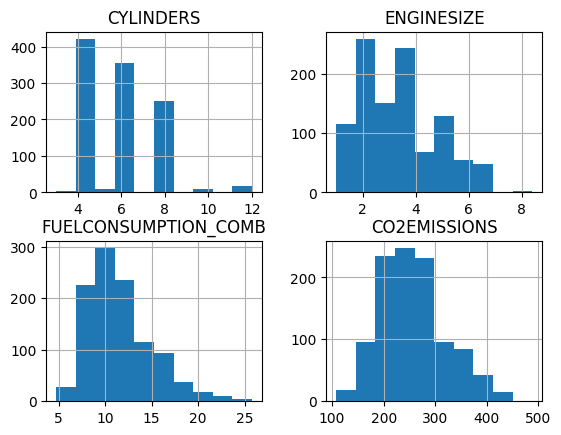

In [15]:
vis = cdf[['CYLINDERS','ENGINESIZE','FUELCONSUMPTION_COMB','CO2EMISSIONS']]
vis.hist()
plt.show()

As we can see, most engines have 4, 6, or 8 cylinders, and engine sizes between 2 and 4 liters.  
As you might expect, combined fuel consumption and CO2 emission have very similar distributions.  
Let's display some scatter plots of these features against the CO2 emissions, to see how linear their relationships are.

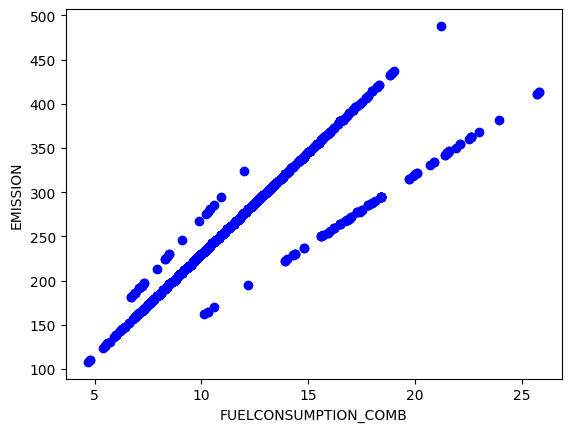

In [18]:
plt.scatter(cdf.FUELCONSUMPTION_COMB,cdf.CO2EMISSIONS, color ='blue')
plt.xlabel("FUELCONSUMPTION_COMB")
plt.ylabel("EMISSION")
plt.show()

This is an informative result. Three car groups each have a strong linear relationship between their combined fuel consumption and their CO2 emissions. 
Their intercepts are similar, while they noticeably differ in their slopes.

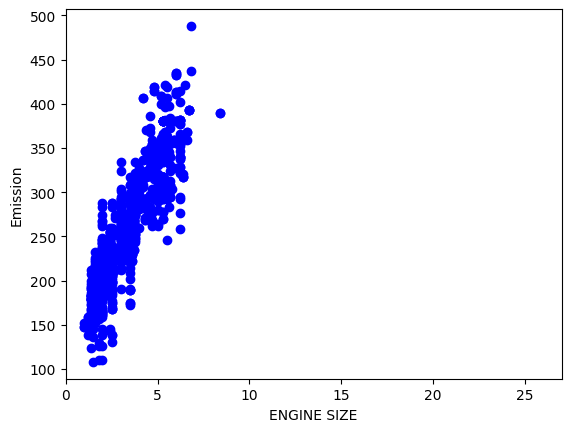

In [22]:
plt.scatter(cdf.ENGINESIZE, cdf.CO2EMISSIONS, color = 'blue')
plt.xlabel("ENGINE SIZE")
plt.ylabel("Emission")
plt.xlim(0,27)
plt.show()

Although the relationship between engine size and CO2 emission is quite linear, we can see that their correlation is weaker than that for each of the three fuel consumption groups. Notice that the x-axis range has been expanded to make the two plots more comparable.

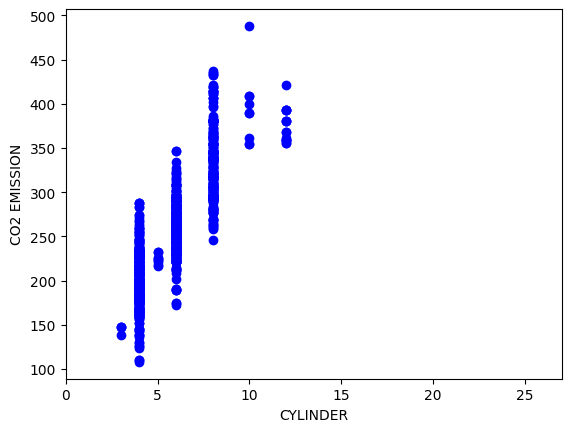

In [23]:
plt.scatter(cdf.CYLINDERS, cdf.CO2EMISSIONS, color = 'blue')
plt.xlabel('CYLINDER')
plt.ylabel("CO2 EMISSION")
plt.xlim(0,27)
plt.show()

### Extract the input feature and labels from the dataset
Although perhaps not necessarily the ideal choice of input feature, for illustration purposes, we will use engine size to predict CO2 emission with a linear regression model.  
We will begin the process by extracting the input feature and target output variables, X and y, from the dataset.

In [24]:
X = cdf.ENGINESIZE.to_numpy()
y = cdf.CO2EMISSIONS.to_numpy()

#### Create train and test datasets
Next, we will split the dataset into mutually exclusive training and testing sets. We will train a simple linear regression model on the training set and estimate its ability to generalize to unseen data by using it to make predictions on the unseen testing data. 

Since the outcome of each data point is part of the testing data, you have a means of evaluating the out-of-sample accuracy of your model.

Now, we will randomly split the data into train and test sets, using 80% of the dataset for training and reserving the remaining 20% for testing. Which fraction to use here mostly depends on the size of your data, but typical testing sizes range from 20% to 30%. The smaller the data, the larger your training set needs to be because it's easier to find spurious patterns in smaller data. The downside is that the evaluation of generalizability will have less reliability. Bigger is better when it comes to data.

In [25]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42)

The outputs are one-dimensional NumPy arrays or vectors.

In [27]:
type(X_train), np.shape(X_train), np.shape(X_train)

(numpy.ndarray, (853,), (853,))